In [ ]:
filepath = 'state_TX.csv'

# **Quelques variables explicatives de la décision**

In [17]:
#@title Analyse des Taux de Prêts Accordés et de Demandes Refusées par Type de Prêt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_loan_action_analysis(file_path):
    # Charger les données
    state_TX = pd.read_csv(file_path, low_memory=False)

    # Remapper les valeurs de 'action_taken'
    action_mapping = {1: 'Loan originated', 3: 'Application denied'}
    state_TX['action_taken_desc'] = state_TX['action_taken'].map(action_mapping)

    # Remapper les valeurs de 'loan_purpose'
    loan_purpose_mapping = {
        1: 'Home purchase', 2: 'Home improvement',
        3: 'Refinancing', 4: 'Other purpose'
    }
    state_TX['loan_purpose_desc'] = state_TX['loan_purpose'].map(loan_purpose_mapping)

    # Filtrer les données pour les actions pertinentes
    filtered_data = state_TX[state_TX['action_taken_desc'].isin(['Loan originated', 'Application denied'])]

    # Calculer le pourcentage par loan_purpose
    loan_purpose_percentage = filtered_data.groupby(['loan_purpose_desc', 'action_taken_desc']).size().unstack(fill_value=0)
    loan_purpose_percentage = loan_purpose_percentage.apply(lambda x: (x / x.sum()) * 100, axis=1)

    # Créer la figure et les axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Graphique pour loan_purpose
    loan_purpose_bars = ax.barh(
        loan_purpose_percentage.index,
        loan_purpose_percentage['Loan originated'],
        color='#4CAF50',
        edgecolor='black',
        linewidth=1.5,
        label='Loan originated'
    )

    # Ajouter les barres pour les demandes refusées
    ax.barh(
        loan_purpose_percentage.index,
        loan_purpose_percentage['Application denied'],
        left=loan_purpose_percentage['Loan originated'],
        color='#F44336',
        edgecolor='black',
        linewidth=1.5,
        label='Application denied'
    )

    # Configurer le graphique
    ax.set_title('Analyse des Taux de Prêts Accordés et de Demandes Refusées par Type de Prêt', fontsize=16)
    ax.set_xlabel('Pourcentage (%)', fontsize=12)
    ax.set_ylabel('Type de Prêt', fontsize=12)
    ax.legend(title='Action Taken')
    plt.xlim(0, 100)  # Limiter l'axe des x à 100%

    # Afficher le graphique
    sns.despine()
    plt.tight_layout()
    plt.show()

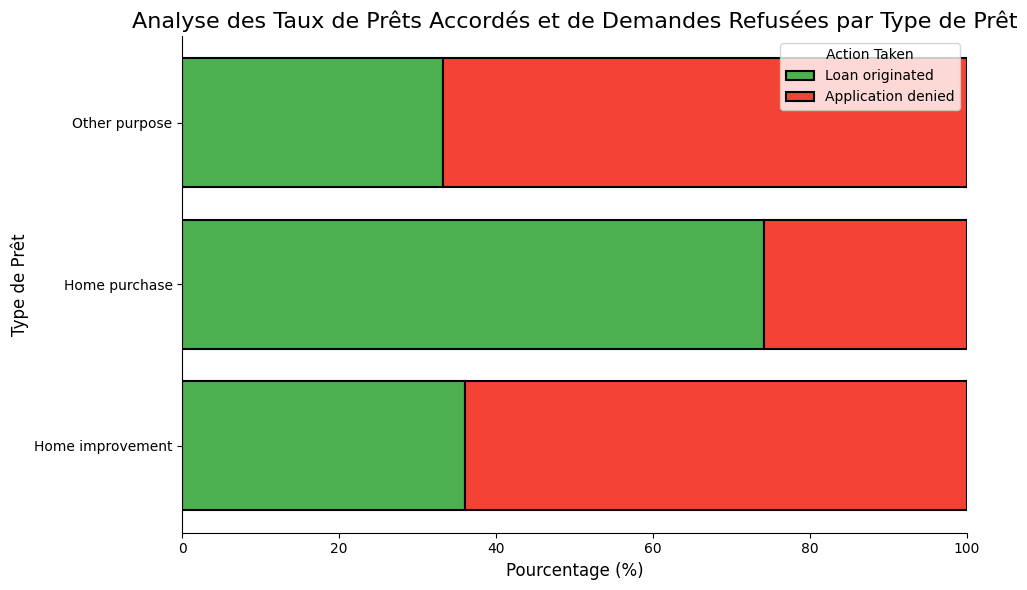

In [3]:
plot_loan_action_analysis(filepath)

Plus de 70 % des demandes de prêts pour l'achat de logements ont été acceptées, indiquant un risque perçu plus faible par les prêteurs. En revanche, moins de 40 % des demandes pour des prêts d'amélioration de l'habitat ont été acceptées, suggérant un risque plus élevé. Cela souligne l'importance du type de projet dans l'évaluation des demandes de crédit.

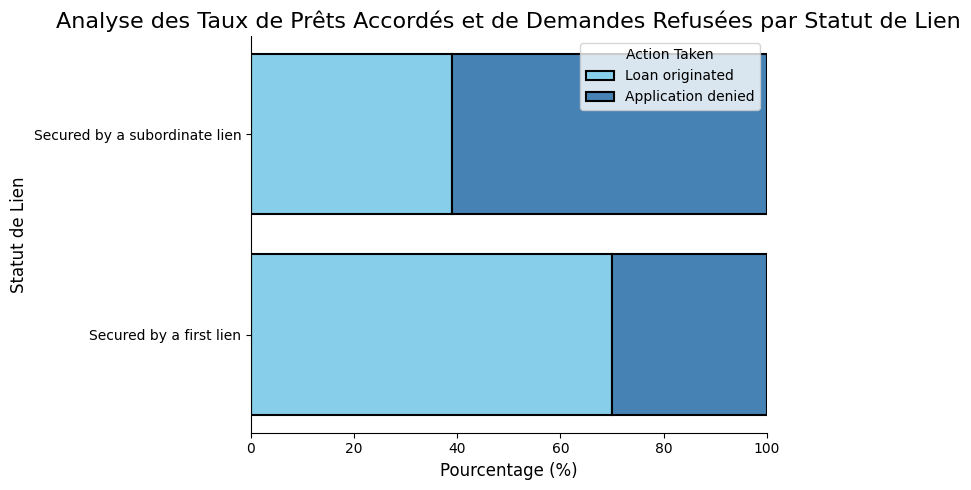

In [24]:
#@title lien status : une variable importante pour la prise de décision
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
state_TX = pd.read_csv(filepath, low_memory=False)

# Remapper les valeurs de 'action_taken'
action_mapping = {1: 'Loan originated', 3: 'Application denied'}
state_TX['action_taken_desc'] = state_TX['action_taken'].map(action_mapping)

# Remapper les valeurs de 'lien_status'
lien_status_mapping = {1: 'Secured by a first lien', 2: 'Secured by a subordinate lien'}
state_TX['lien_status_desc'] = state_TX['lien_status'].map(lien_status_mapping)

# Filtrer les données pour les actions pertinentes
filtered_data = state_TX[state_TX['action_taken_desc'].isin(['Loan originated', 'Application denied'])]

# Calculer le pourcentage par lien_status
lien_status_percentage = filtered_data.groupby(['lien_status_desc', 'action_taken_desc']).size().unstack(fill_value=0)
lien_status_percentage = lien_status_percentage.apply(lambda x: (x / x.sum()) * 100, axis=1)

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(8, 5))

# Graphique pour lien_status
lien_status_bars = ax.barh(
    lien_status_percentage.index,
    lien_status_percentage['Loan originated'],
    color='#87CEEB',
    edgecolor='black',
    linewidth=1.5,
    label='Loan originated'
)

# Ajouter les barres pour les demandes refusées
ax.barh(
    lien_status_percentage.index,
    lien_status_percentage['Application denied'],
    left=lien_status_percentage['Loan originated'],
    color='#4682B4',
    edgecolor='black',
    linewidth=1.5,
    label='Application denied'
)

# Configurer le graphique
ax.set_title('Analyse des Taux de Prêts Accordés et de Demandes Refusées par Statut de Lien', fontsize=16)
ax.set_xlabel('Pourcentage (%)', fontsize=12)
ax.set_ylabel('Statut de Lien', fontsize=12)
ax.legend(title='Action Taken')
plt.xlim(0, 100)  # Limiter l'axe des x à 100%

# Afficher le graphique
sns.despine()
plt.tight_layout()
plt.show()

Le taux d'acceptation des crédits diffère significativement entre les prêts de premier lien et les prêts subordonnés. Les prêts de premier lien sont généralement considérés comme moins risqués pour les prêteurs, car ils ont la priorité sur les actifs en cas de défaut de paiement.

In [19]:
#@title Existe-t-il des Biais Discriminatoires dans l'Octroi de Prêts en Fonction de la Race et de l'Éthnicité ?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(file_path):
    """Load data from CSV file and map action_taken, derived_sex, derived_race, and derived_ethnicity."""
    state_TX = pd.read_csv(file_path, low_memory=False)

    # Remapper les valeurs de 'action_taken'
    action_mapping = {
        1: 'Loan originated',
        2: 'Application approved but not accepted',
        3: 'Application denied',
        4: 'Application withdrawn by applicant',
        5: 'File closed for incompleteness',
        6: 'Purchased loan',
        7: 'Preapproval request denied',
        8: 'Preapproval request approved but not accepted'
    }
    state_TX['action_taken_desc'] = state_TX['action_taken'].map(action_mapping)

    # Remapper les valeurs de 'derived_sex'
    sex_mapping = {
        'Male': 'Male',
        'Female': 'Female',
        'Joint': 'Joint',
        'Sex Not Available': 'Not Available'
    }
    state_TX['derived_sex_desc'] = state_TX['derived_sex'].map(sex_mapping)

    # Remapper les valeurs de 'derived_race'
    race_mapping = {
        'American Indian or Alaska Native': 'American Indian',
        'Asian': 'Asian',
        'Black or African American': 'Black',
        'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
        'White': 'White',
        '2 or more minority races': '2+ Minority Races',
        'Joint': 'Joint',
        'Free Form Text Only': 'Free Form',
        'Race Not Available': 'Not Available'
    }
    state_TX['derived_race_desc'] = state_TX['derived_race'].map(race_mapping)

    # Remapper les valeurs de 'derived_ethnicity'
    ethnicity_mapping = {
        'Hispanic or Latino': 'Hispanic',
        'Not Hispanic or Latino': 'Not Hispanic',
        'Joint': 'Joint',
        'Ethnicity Not Available': 'Not Available',
        'Free Form Text Only': 'Free Form'
    }
    state_TX['derived_ethnicity_desc'] = state_TX['derived_ethnicity'].map(ethnicity_mapping)

    return state_TX

def plot_sex_distribution(data, ax):
    """Plot loan distribution by sex."""
    filtered_data = data[data['action_taken_desc'].isin(['Loan originated', 'Application denied'])]
    sex_percentage = filtered_data.groupby(['derived_sex_desc', 'action_taken_desc']).size().unstack(fill_value=0)
    sex_percentage = sex_percentage.apply(lambda x: (x / x.sum()) * 100, axis=1)

    bars = ax.bar(sex_percentage.index, sex_percentage['Loan originated'], color='#FF9999', edgecolor='black', linewidth=1.5, label='Loan originated')
    ax.bar(sex_percentage.index, sex_percentage['Application denied'], bottom=sex_percentage['Loan originated'], color='#66B2FF', edgecolor='black', linewidth=1.5, label='Application denied')
    ax.set_title('Par Sexe', fontsize=14)
    ax.set_ylabel('Pourcentage (%)', fontsize=12)
    ax.legend(title='Action Taken', loc='upper right')
    ax.bar_label(bars)

def plot_race_distribution(data, ax):
    """Plot loan distribution by race."""
    race_percentage = data.groupby(['derived_race_desc', 'action_taken_desc']).size().unstack(fill_value=0)
    race_percentage = race_percentage.apply(lambda x: (x / x.sum()) * 100, axis=1)

    ax.barh(race_percentage.index, race_percentage['Loan originated'], color='#FFCC99', edgecolor='black', linewidth=1.5, label='Loan originated')
    ax.barh(race_percentage.index, race_percentage['Application denied'], left=race_percentage['Loan originated'], color='#99FF99', edgecolor='black', linewidth=1.5, label='Application denied')

    for index, value in enumerate(race_percentage['Loan originated']):
        ax.text(value + 1, index, f'{value:.1f}%', va='center')

    for index, value in enumerate(race_percentage['Application denied']):
        ax.text(race_percentage['Loan originated'][index] + value + 1, index, f'{value:.1f}%', va='center')

    ax.set_title('Par Race', fontsize=14)
    ax.set_xlabel('Pourcentage (%)', fontsize=12)
    ax.legend(title='Action Taken', loc='upper right')

def plot_ethnicity_distribution(data, ax):
    """Plot loan distribution by ethnicity."""
    ethnicity_percentage = data.groupby(['derived_ethnicity_desc', 'action_taken_desc']).size().unstack(fill_value=0)
    ethnicity_percentage = ethnicity_percentage.apply(lambda x: (x / x.sum()) * 100, axis=1)

    bars = ax.bar(ethnicity_percentage.index, ethnicity_percentage['Loan originated'], color='#FFB3E6', edgecolor='black', linewidth=1.5, label='Loan originated')
    ax.bar(ethnicity_percentage.index, ethnicity_percentage['Application denied'], bottom=ethnicity_percentage['Loan originated'], color='#B3B3FF', edgecolor='black', linewidth=1.5, label='Application denied')
    ax.set_title('Par Ethnicité', fontsize=14)
    ax.set_xlabel('Ethnicité', fontsize=12)
    ax.legend(title='Action Taken', loc='upper right')
    ax.bar_label(bars)

def main():
    # Charger les données
    data = load_data(filepath)

    # Créer la figure et les axes
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Plotting
    plot_sex_distribution(data, axs[0])
    plot_race_distribution(data, axs[1])
    plot_ethnicity_distribution(data, axs[2])

    # Configuration de l'affichage
    plt.tight_layout()
    plt.suptitle('Analyse des Taux de Prêts Accordés et de Demandes Refusées', fontsize=20)
    plt.subplots_adjust(top=0.85)  # Ajuster l'espace pour le titre
    plt.show()



<ipython-input-10-b8bd919566f7>:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(race_percentage['Loan originated'][index] + value + 1, index, f'{value:.1f}%', va='center')


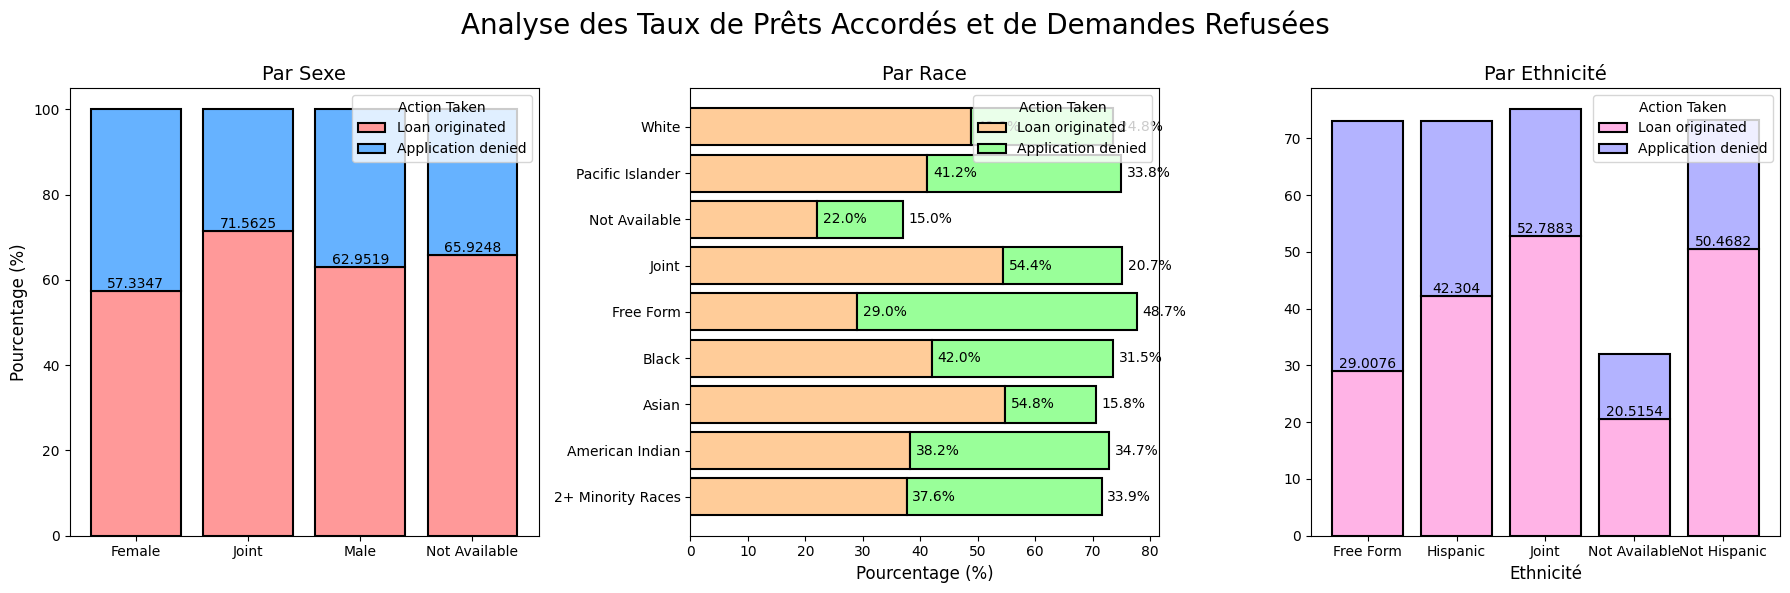

In [11]:
if __name__ == '__main__':
    main()

L'analyse des taux de prêts accordés révèle peu de différences selon le sexe, indiquant un traitement équitable. En revanche, des disparités significatives sont observées par race et ethnicité, suggérant des biais discriminatoires potentiels. Il reste à explorer d'autres variables pour déterminer si ces différences sont justifiées ou non.

In [20]:
#@title Analyse du rate_spread

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_rate_spread_by_race(file_path):
    # Charger les données
    state_TX = pd.read_csv(file_path, low_memory=False)

    # Remapper les valeurs de 'derived_race'
    race_mapping = {
        'American Indian or Alaska Native': 'American Indian',
        'Asian': 'Asian',
        'Black or African American': 'Black',
        'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
        'White': 'White',
        '2 or more minority races': '2+ Minority Races',
        'Joint': 'Joint',
        'Free Form Text Only': 'Free Form',
        'Race Not Available': 'Not Available'
    }
    state_TX['derived_race_desc'] = state_TX['derived_race'].map(race_mapping)

    # Convertir 'rate_spread' en numérique
    state_TX['rate_spread'] = pd.to_numeric(state_TX['rate_spread'], errors='coerce')

    # Vérifier les valeurs NaN après conversion
    print(f'Number of NaN values in rate_spread: {state_TX["rate_spread"].isna().sum()}')

    # Supprimer les lignes avec NaN dans 'rate_spread'
    state_TX = state_TX.dropna(subset=['rate_spread'])

    # Grouper par 'derived_race_desc' et calculer la moyenne et l'écart type
    rate_spread_by_race = state_TX.groupby('derived_race_desc')['rate_spread'].agg(['mean', 'std']).reset_index()

    # Calculer l'erreur standard
    rate_spread_by_race['error'] = rate_spread_by_race['std'] / np.sqrt(state_TX.groupby('derived_race_desc')['rate_spread'].count().values)

    # Créer le graphique à barres
    plt.figure(figsize=(12, 6))
    bars = sns.barplot(x='derived_race_desc', y='mean', data=rate_spread_by_race, palette='muted', ci=None)

    # Ajouter des barres d'erreur
    plt.errorbar(x=rate_spread_by_race['derived_race_desc'],
                 y=rate_spread_by_race['mean'],
                 yerr=rate_spread_by_race['error'],
                 fmt='none', c='black', capsize=5)

    # Définir les titres et les étiquettes
    plt.title('Taux Moyen de Rate Spread par Race', fontsize=16)
    plt.xlabel('Race', fontsize=12)
    plt.ylabel('Rate Spread (Moyenne)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Afficher le graphique
    plt.show()


Number of NaN values in rate_spread: 366707


<ipython-input-5-f0cfb354f3bf>:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bars = sns.barplot(x='derived_race_desc', y='mean', data=rate_spread_by_race, palette='muted', ci=None)
<ipython-input-5-f0cfb354f3bf>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='derived_race_desc', y='mean', data=rate_spread_by_race, palette='muted', ci=None)


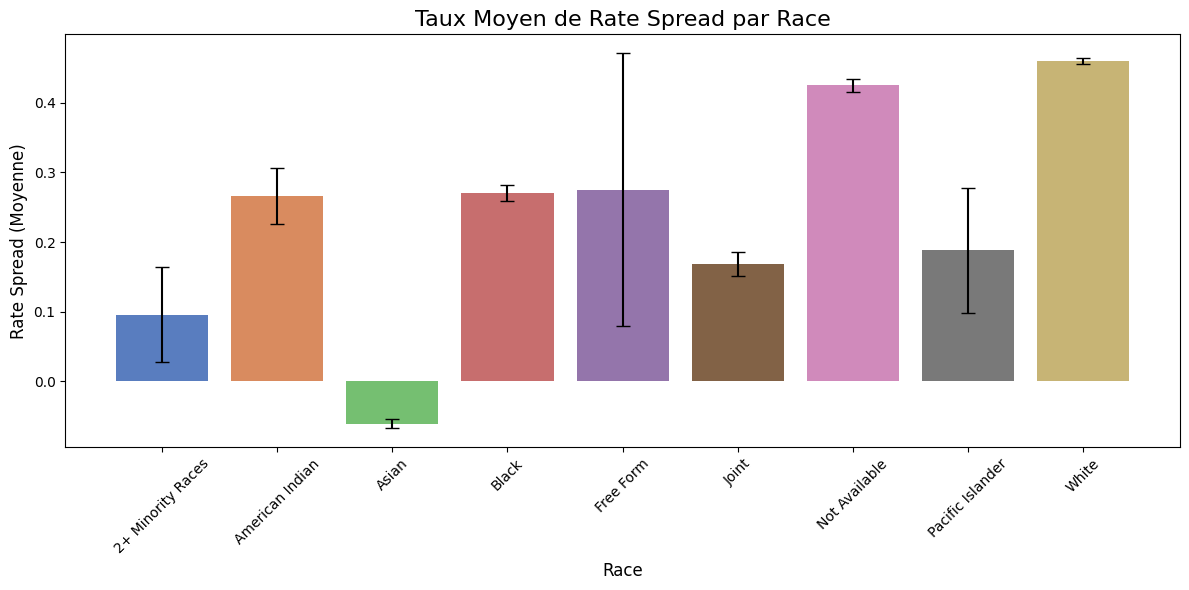

In [6]:
analyze_rate_spread_by_race(filepath)

le rate spread, qui représente la différence entre le taux d'intérêt du prêt et le taux de référence, montre de grandes disparités entre les races, suggérant que certains groupes pourraient faire face à des conditions de crédit moins favorables.

# **Problème de data science**

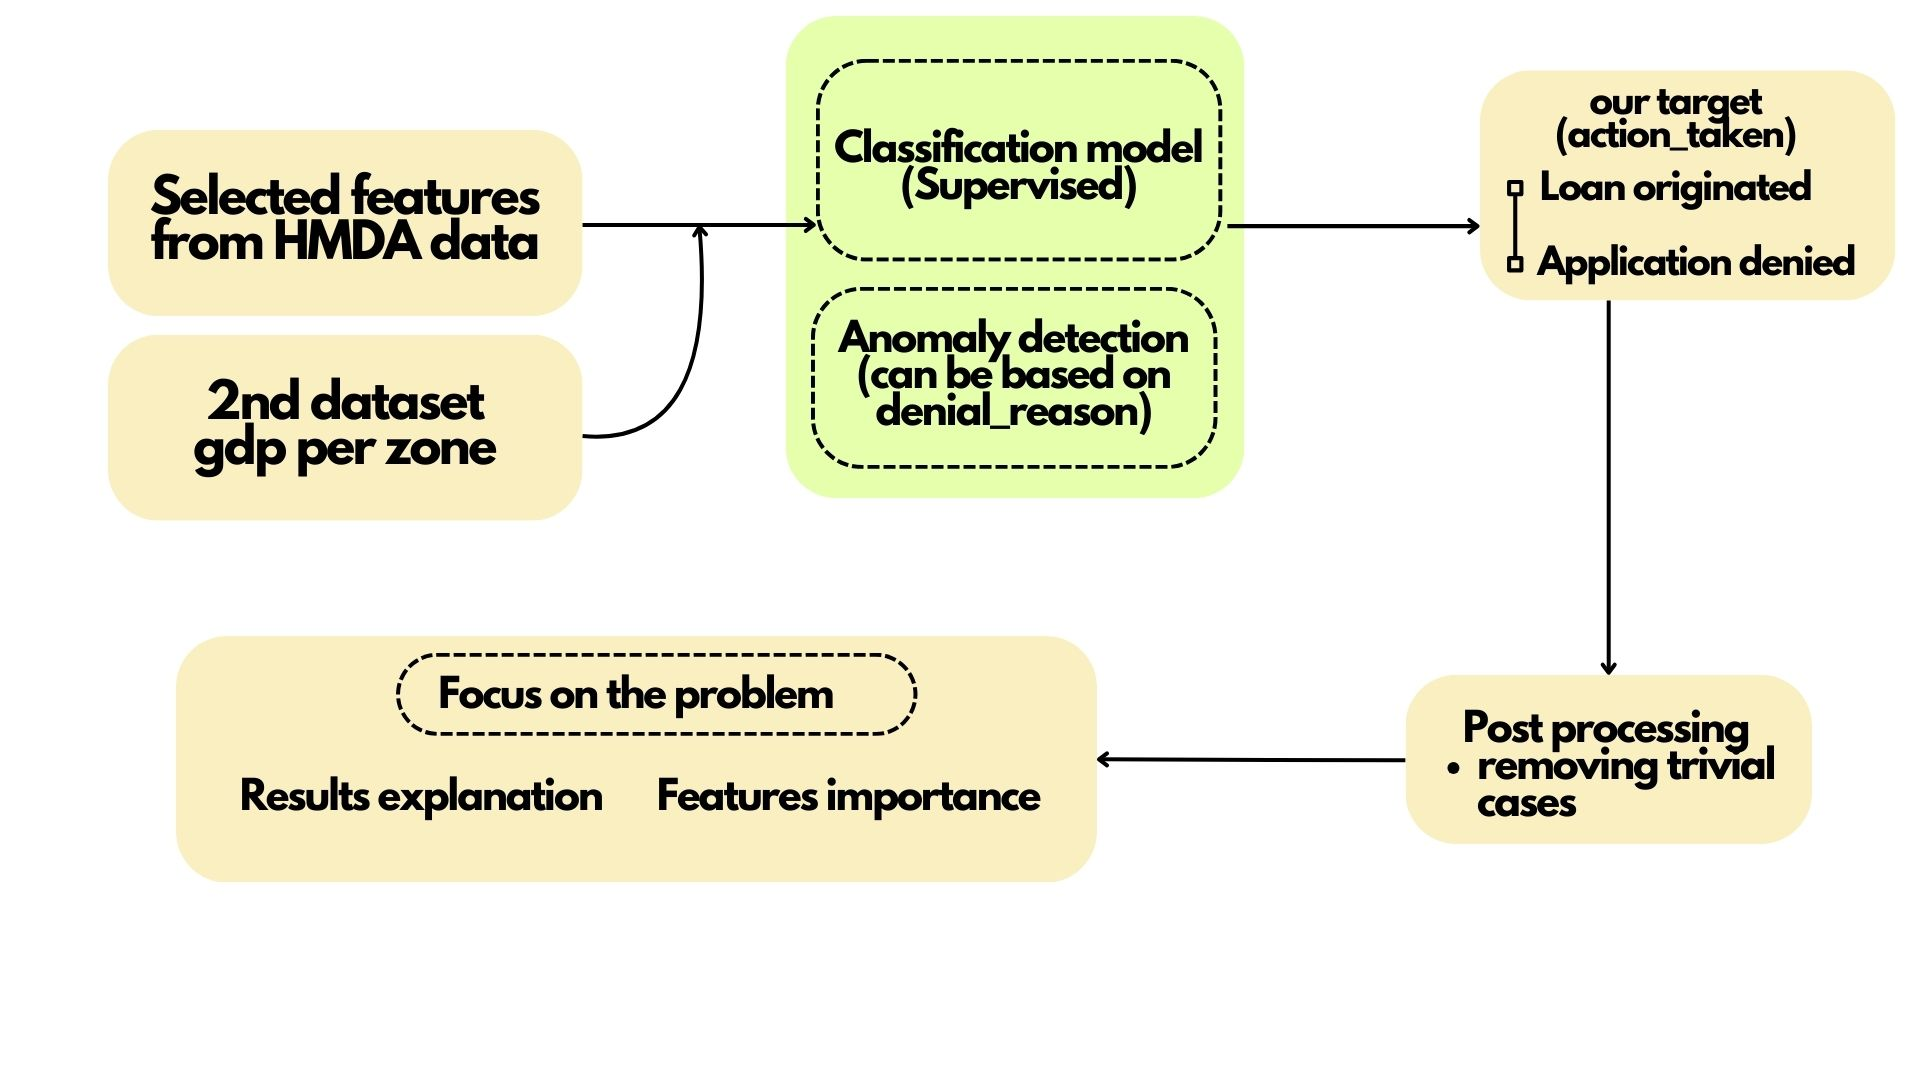

Le dataset HMDA contient plusieurs variables explicatives de la variable cible "action_taken," que nous cherchons à modéliser dans un premier temps selon deux classes : "application denied" (demande refusée) ou "loan originated" (prêt accordé). Après une étape de sélection des variables les plus pertinentes et une combinaison avec un deuxième jeu de données présentant les taux de richesse par zones, deux approches sont envisagées :

* Classification supervisée : Nous utiliserons des algorithmes d'apprentissage supervisé basés sur les variables sélectionnées pour prédire la décision d'acceptation ou de refus de l'offre. Cette approche permettra de mieux comprendre les facteurs influençant la décision, et de détecter, après suppression des cas triviaux, la présence de biais discriminatoires potentiels dans les décisions de prêt.

* Détection d'anomalies : En complément, une seconde approche consistera à examiner le motif de décision. En utilisant des techniques de détection d'anomalies, nous chercherons à relever des incohérences ou des irrégularités dans les décisions prises, ce qui pourrait révéler des cas suspects ou des biais non explicites.

Ces deux approches nous permettront d'approfondir l'analyse des décisions et de mieux comprendre les dynamiques discriminatoires qui peuvent exister dans les décisions de prêt et donc répondre à notre problématique.





Par la suite, nous nous intéresserons à ce qui se passe lorsque le prêt est accordé, en étudiant le comportement du demandeur : pourquoi certains choisissent-ils de refuser l'offre, même après acceptation ? Cette analyse permettra de vérifier s'il existe d'autres formes de biais qui pourraient influencer la décision des demandeurs, tels que des rajouts de taux ("rate_spread") non équitables ou d'autres pratiques discriminatoires qui rendraient l'offre moins attractive, malgré l'acceptation initiale par la banque.